# CÍL 5: ÚKOL – Segmentace medicínských snímků

> Tento notebook je součástí cvičení 9 předmětu BPC-PRG.  
> 📥 **[Stáhnout notebook (cviceni_09_segmentace.ipynb)](cviceni_09_segmentace.ipynb)**


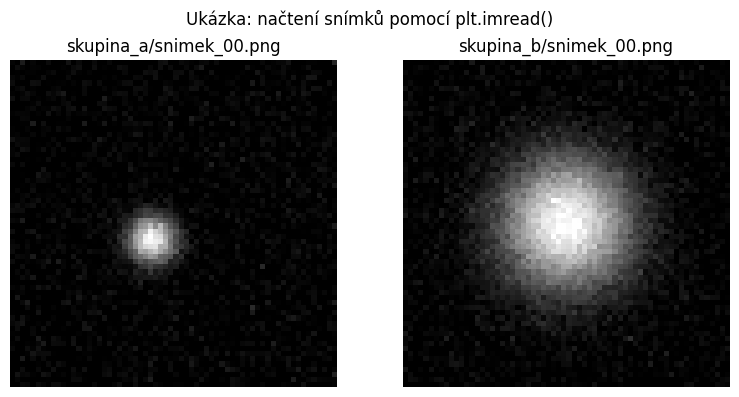

Tvar pole: (64, 64), hodnoty: min=0.000, max=1.000


In [1]:
# Ukázkové načtení a zobrazení dvou snímků pomocí pevně zadané cesty
# Spuštěním této buňky ověříš, že jsou soubory dostupné a funkce plt.imread() funguje
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

snimek_a = plt.imread("skupina_a/snimek_00.png")[:, :, 0]
snimek_b = plt.imread("skupina_b/snimek_00.png")[:, :, 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.imshow(snimek_a, cmap="gray", vmin=0, vmax=1)
ax1.set_title("skupina_a/snimek_00.png")
ax1.axis("off")
ax2.imshow(snimek_b, cmap="gray", vmin=0, vmax=1)
ax2.set_title("skupina_b/snimek_00.png")
ax2.axis("off")
plt.suptitle("Ukázka: načtení snímků pomocí plt.imread()")
plt.tight_layout()
plt.show()
print(f"Tvar pole: {snimek_a.shape}, hodnoty: min={snimek_a.min():.3f}, max={snimek_a.max():.3f}")


## Zadání

Máš k dispozici dvě skupiny simulovaných medicínských snímků ve složkách
`skupina_a/` a `skupina_b/` (5 snímků `.png` v každé složce):

- **`skupina_a/`** – „Zdravá tkáň": malý, kompaktní jasný region (~20 % plochy)
- **`skupina_b/`** – „Nádorová tkáň": velký, rozlitý jasný region (~45 % plochy)

Snímky načteš pomocí `plt.imread()`. Ten vrátí RGBA pole tvaru `(64, 64, 4)` –
pro práci s intenzitou stačí vzít první kanál: `snimek = plt.imread(...)[:, :, 0]`

Proveď postupně tyto kroky:

1. **Načti data** – načti všechny snímky ze složek a zobraz první snímek z každé skupiny.
2. **Prahování** – naprahuj jeden snímek, vytvoř binární masku a zobraz ji vedle originálu.
3. **Kvantitativní analýza** – spočítej poměrnou plochu pokrytou strukturou a průměrnou intenzitu uvnitř masky.
4. **Srovnání skupin** – zpracuj všechny snímky obou skupin a porovnej poměrné plochy boxplotem.


Načteno snímků skupiny A: 5, tvar: (64, 64)
Načteno snímků skupiny B: 5, tvar: (64, 64)


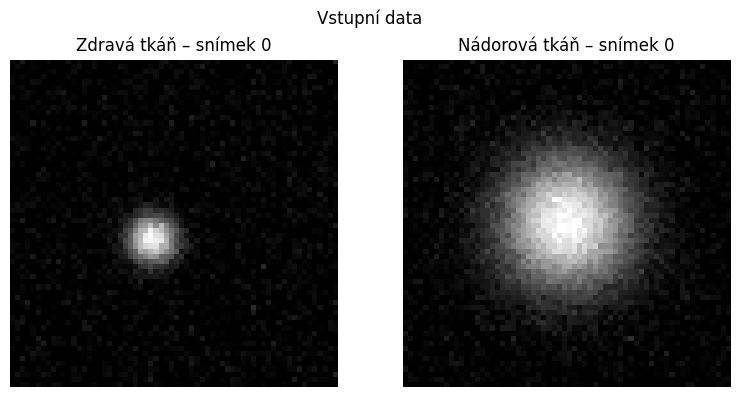

In [2]:
%matplotlib inline
import glob
import numpy as np
import matplotlib.pyplot as plt

# Krok 1 – načtení snímků
files_a = sorted(glob.glob("skupina_a/*.png"))
files_b = sorted(glob.glob("skupina_b/*.png"))

# plt.imread vrátí RGBA pole (64, 64, 4) – bereme jen první kanál (intenzita)
skupina_a = [plt.imread(f)[:, :, 0] for f in files_a]
skupina_b = [plt.imread(f)[:, :, 0] for f in files_b]

print(f"Načteno snímků skupiny A: {len(skupina_a)}, tvar: {skupina_a[0].shape}")
print(f"Načteno snímků skupiny B: {len(skupina_b)}, tvar: {skupina_b[0].shape}")

# Zobrazení prvního snímku z každé skupiny
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.imshow(skupina_a[0], cmap="gray", vmin=0, vmax=1)
ax1.set_title("Zdravá tkáň – snímek 0")
ax1.axis("off")
ax2.imshow(skupina_b[0], cmap="gray", vmin=0, vmax=1)
ax2.set_title("Nádorová tkáň – snímek 0")
ax2.axis("off")
plt.suptitle("Vstupní data")
plt.tight_layout()
plt.show()


### Krok 2 – Prahování a vizualizace masky

Naprahuj snímek – vytvoř **binární masku**: NumPy pole `bool`, kde `True` = pixel patří do struktury.

```python
maska = snimek > PRAH
```

Zobraz vedle sebe původní snímek a binární masku.


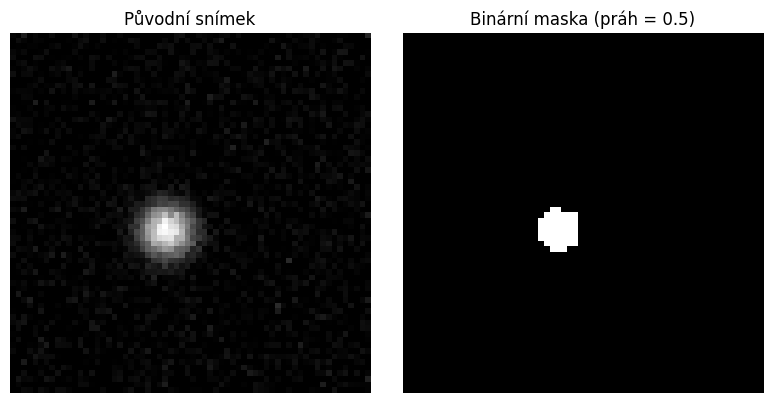

In [3]:
# Krok 2 – prahování
PRAH = 0.5
snimek = skupina_a[0]

maska = snimek > PRAH

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.imshow(snimek, cmap="gray", vmin=0, vmax=1)
ax1.set_title("Původní snímek")
ax1.axis("off")
ax2.imshow(maska, cmap="gray")
ax2.set_title(f"Binární maska (práh = {PRAH})")
ax2.axis("off")
plt.tight_layout()
plt.show()


### Krok 3 – Kvantitativní analýza

Pro snímek a masku z Kroku 2 spočítej:

- **poměrnou plochu struktury** – kolik % pixelů je `True` v masce  
  `podil = maska.sum() / maska.size * 100`
- **průměrnou intenzitu** – průměr hodnot pixelů *uvnitř* masky  
  `mean_int = snimek[maska].mean()`


In [4]:
# Krok 3 – kvantitativní analýza
podil    = maska.sum() / maska.size * 100
mean_int = snimek[maska].mean()

print(f"Plocha struktury: {podil:.1f} %")
print(f"Průměrná intenzita: {mean_int:.3f}")


Plocha struktury: 1.1 %
Průměrná intenzita: 0.714


### Krok 4 – Srovnání skupin: boxplot

Zpracuj **všechny snímky** obou skupin: pro každý snímek spočítej poměrnou plochu
při `PRAH = 0.5`. Výsledky ulož do dvou seznamů a vykresli boxplot.


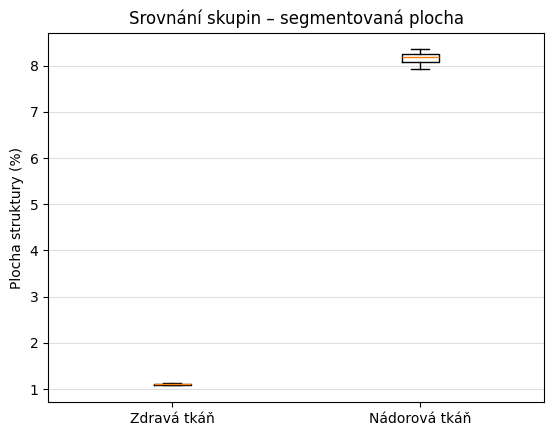

Skupina A (zdravá tkáň): ['1.1 %', '1.1 %', '1.1 %', '1.1 %', '1.1 %']
Skupina B (nádorová tkáň): ['8.1 %', '8.3 %', '8.3 %', '7.9 %', '8.2 %']


In [5]:
# Krok 4 – srovnání skupin
PRAH = 0.5

podily_a = []
for snimek in skupina_a:
    maska = snimek > PRAH
    podil = maska.sum() / maska.size * 100
    podily_a.append(podil)

podily_b = []
for snimek in skupina_b:
    maska = snimek > PRAH
    podil = maska.sum() / maska.size * 100
    podily_b.append(podil)

fig, ax = plt.subplots()
ax.boxplot([podily_a, podily_b], tick_labels=["Zdravá tkáň", "Nádorová tkáň"])
ax.set_ylabel("Plocha struktury (%)")
ax.set_title("Srovnání skupin – segmentovaná plocha")
ax.grid(True, axis="y", alpha=0.4)
plt.show()

print("Skupina A (zdravá tkáň):", [f"{p:.1f} %" for p in podily_a])
print("Skupina B (nádorová tkáň):", [f"{p:.1f} %" for p in podily_b])


### Interpretace

*Sem napiš, jak se skupiny liší a co by mohl výsledek znamenat klinicky.*
